In [1]:
# ==========================================================
# Notebook 05: PV sizing and self-consumption
#
# Goal:
# Study how different PV system sizes affect:
# - PV production
# - direct self-consumption
# - grid import
# - excess/exported PV energy
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [4]:
# ==========================================================
# Load yearly OSOPSS data
#
# load_all_year     : building load [kW]
# zeta_PV           : normalized PV production [kW/kWp]
# prices_all_year   : electricity price [EUR/kWh]
# ==========================================================

load_mat = loadmat("../data/raw/load_yearly.mat")
pv_mat = loadmat("../data/raw/PV_production_yearly.mat")
price_mat = loadmat("../data/raw/prices_yearly.mat")

load_year = load_mat["load_all_year"].flatten()
pv_factor = pv_mat["zeta_PV"].flatten()
price_year = price_mat["prices_all_year"].flatten()

print("Load shape :", load_year.shape)
print("PV shape   :", pv_factor.shape)
print("Price shape:", price_year.shape)

Load shape : (8760,)
PV shape   : (8760,)
Price shape: (8760,)


In [ ]:
# ==========================================================
# Choose an initial PV size
#
# In the MATLAB yearly sizing code, the PV size is an
# optimization variable S_PV [kWp].
#
# Here we first choose a fixed PV size manually.
# Later, optimization will select this automatically.
# ==========================================================
    
S_PV = 300  # PV system size [kWp]

pv_power = S_PV * pv_factor  # hourly PV production [kW]

print("PV size [kWp]:", S_PV)
print("Annual PV energy [kWh]:", pv_power.sum())

PV size [kWp]: 300
Annual PV energy [kWh]: 336462.363


In [6]:
# ==========================================================
# Direct PV self-consumption without battery
#
# At each hour:
# - If PV <= load, all PV is consumed locally.
# - If PV > load, only part is consumed and the rest is excess.
# ==========================================================

pv_self_consumed = np.minimum(pv_power, load_year)

grid_import = np.maximum(load_year - pv_power, 0)

pv_excess = np.maximum(pv_power - load_year, 0)

print("Annual load energy [kWh]:", load_year.sum())
print("Annual PV energy [kWh]:", pv_power.sum())
print("PV self-consumed [kWh]:", pv_self_consumed.sum())
print("Grid import [kWh]:", grid_import.sum())
print("PV excess/export [kWh]:", pv_excess.sum())

Annual load energy [kWh]: 500000.00000001164
Annual PV energy [kWh]: 336462.363
PV self-consumed [kWh]: 222935.59547139745
Grid import [kWh]: 277064.40452861413
PV excess/export [kWh]: 113526.76752860256


In [7]:
# ==========================================================
# Key performance indicators
# ==========================================================

self_consumption_ratio = pv_self_consumed.sum() / pv_power.sum()

load_coverage_ratio = pv_self_consumed.sum() / load_year.sum()

print("PV self-consumption ratio:", self_consumption_ratio)
print("Load coverage ratio:", load_coverage_ratio)

PV self-consumption ratio: 0.6625870230584971
Load coverage ratio: 0.44587119094278455


This means that 44.6 % of the building's yearly demand is already covered by PV.

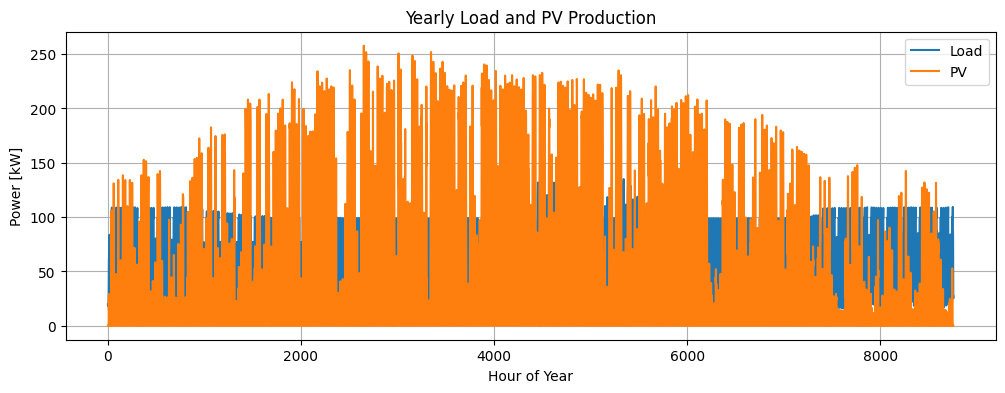

In [8]:
# ==========================================================
# Plot load and PV production for the entire year
#
# This helps identify periods where:
# PV > Load  --> excess energy available
# PV < Load  --> grid import required
# ==========================================================

plt.figure(figsize=(12,4))

plt.plot(load_year, label="Load")
plt.plot(pv_power, label="PV")

plt.title("Yearly Load and PV Production")
plt.xlabel("Hour of Year")
plt.ylabel("Power [kW]")

plt.legend()
plt.grid()

plt.show()

Test multiple PV sizes.

In [9]:
# ==========================================================
# PV sizing study
#
# We evaluate several PV sizes and compute:
#
# 1. Annual PV production
# 2. Self-consumed PV energy
# 3. Excess PV energy
# 4. Load coverage
#
# This reproduces the first step of the MATLAB sizing study.
# ==========================================================

pv_sizes = [100, 200, 300, 400, 500, 600]

for S_PV in pv_sizes:

    pv_power = S_PV * pv_factor

    pv_self_consumed = np.minimum(pv_power, load_year)

    pv_excess = np.maximum(pv_power - load_year, 0)

    self_consumption_ratio = (
        pv_self_consumed.sum()
        / pv_power.sum()
    )

    load_coverage_ratio = (
        pv_self_consumed.sum()
        / load_year.sum()
    )

    print("\nPV size:", S_PV, "kWp")

    print(
        "Self-consumption:",
        round(self_consumption_ratio * 100, 1),
        "%"
    )

    print(
        "Load coverage:",
        round(load_coverage_ratio * 100, 1),
        "%"
    )

    print(
        "Excess PV:",
        round(pv_excess.sum()),
        "kWh/year"
    )


PV size: 100 kWp
Self-consumption: 98.8 %
Load coverage: 22.2 %
Excess PV: 1365 kWh/year

PV size: 200 kWp
Self-consumption: 84.6 %
Load coverage: 37.9 %
Excess PV: 34617 kWh/year

PV size: 300 kWp
Self-consumption: 66.3 %
Load coverage: 44.6 %
Excess PV: 113527 kWh/year

PV size: 400 kWp
Self-consumption: 54.1 %
Load coverage: 48.5 %
Excess PV: 205886 kWh/year

PV size: 500 kWp
Self-consumption: 45.8 %
Load coverage: 51.3 %
Excess PV: 304122 kWh/year

PV size: 600 kWp
Self-consumption: 39.7 %
Load coverage: 53.5 %
Excess PV: 405511 kWh/year


In [10]:
# Store PV sizing results in a structured table

pv_results = []

for S_PV in pv_sizes:
    pv_power = S_PV * pv_factor
    pv_self_consumed = np.minimum(pv_power, load_year)
    pv_excess = np.maximum(pv_power - load_year, 0)

    pv_results.append({
        "PV size [kWp]": S_PV,
        "Annual PV energy [kWh]": pv_power.sum(),
        "Self-consumed PV [kWh]": pv_self_consumed.sum(),
        "Excess PV [kWh]": pv_excess.sum(),
        "Self-consumption [%]": 100 * pv_self_consumed.sum() / pv_power.sum(),
        "Load coverage [%]": 100 * pv_self_consumed.sum() / load_year.sum(),
    })

pv_results_df = pd.DataFrame(pv_results)

pv_results_df

,PV size [kWp],Annual PV energy [kWh],Self-consumed PV [kWh],Excess PV [kWh],Self-consumption [%],Load coverage [%]
0,100,112154.121,110788.685842,1365.435158,98.782537,22.157737
1,200,224308.242,189691.405647,34616.836353,84.567292,37.938281
2,300,336462.363,222935.595471,113526.767529,66.258702,44.587119
3,400,448616.484,242730.341244,205886.142756,54.106425,48.546068
4,500,560770.605,256648.393462,304122.211538,45.767091,51.329679
5,600,672924.726,267413.261155,405511.464845,39.738956,53.482652


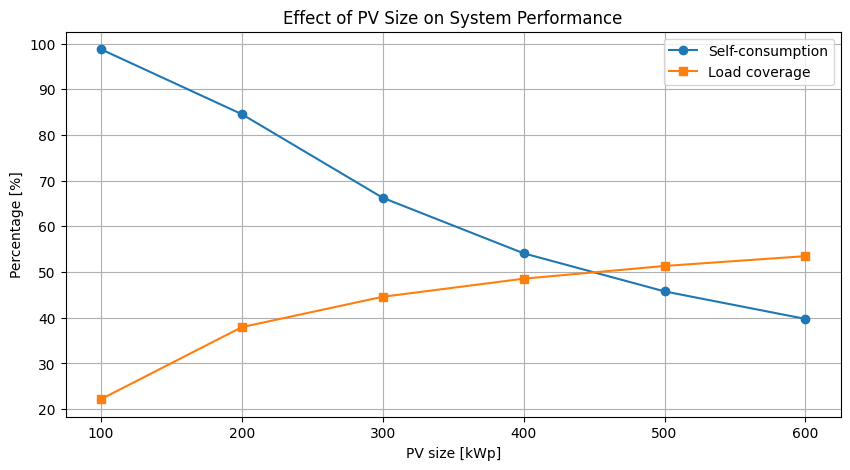

In [11]:
# ==========================================================
# Plot PV sizing indicators
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    pv_results_df["PV size [kWp]"],
    pv_results_df["Self-consumption [%]"],
    marker="o",
    label="Self-consumption"
)

plt.plot(
    pv_results_df["PV size [kWp]"],
    pv_results_df["Load coverage [%]"],
    marker="s",
    label="Load coverage"
)

plt.xlabel("PV size [kWp]")
plt.ylabel("Percentage [%]")
plt.title("Effect of PV Size on System Performance")
plt.grid()
plt.legend()

plt.show()